# 🚖 Ride Booking Data Analysis

Exploratory Data Analysis (EDA) performed using Python to understand ride patterns, cancellations, and demand trends.

## Import Required Libraries

In this step, we import the Python libraries required for data analysis and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

The dataset is loaded using pandas to begin the analysis.  
We also preview the first few rows to understand the structure of the dataset.

In [2]:
df = pd.read_csv('ncr_ride_bookings.csv')
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,23-03-2024,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29-11-2024,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,23-08-2024,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,21-10-2024,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,16-09-2024,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

## Missing Values Analysis

Before performing data cleaning, we check for missing values in the dataset.  
This helps identify columns that contain null values and require cleaning or removal.

In [4]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [5]:
df.shape

(150000, 21)

## 🧹 Data Cleaning

- Removed unnecessary columns if needed
- Handled missing values appropriately
- Converted columns to correct data types

In [6]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')

In [7]:
df['Booking Value'] = df['Booking Value'].fillna(0)
df['Cancelled Rides by Driver'] = df['Cancelled Rides by Driver'].fillna(0)
df['Cancelled Rides by Customer'] = df['Cancelled Rides by Customer'].fillna(0)
df['Incomplete Rides'] = df['Incomplete Rides'].fillna(0)
df['Payment Method'] = df['Payment Method'].fillna('Unknown')

## Final Dataset Structure

After completing the cleaning process, we review the dataset structure again to confirm that all columns have appropriate data types and no critical missing values remain.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  datetime64[ns]
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by C

## 📊 Booking Status Analysis

Analyzed distribution of completed and cancelled rides.

In [9]:
df['Booking Status'].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

In [10]:
(df['Booking Status'].value_counts(normalize=True) * 100)

Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: proportion, dtype: float64

## 🚗 Vehicle Type Analysis

Examined usage of different vehicle types.

In [11]:
pd.crosstab(df['Vehicle Type'], df['Booking Status'])

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Vehicle Type,,,,,
Auto,2680,6643,23155,2260,2681
Bike,1575,4077,14034,1328,1503
Go Mini,2097,5330,18549,1815,2015
Go Sedan,1832,5031,16676,1642,1960
Premier Sedan,1266,3250,11252,1063,1280
Uber XL,327,762,2783,262,315
eBike,723,1907,6551,630,746


## 📊 Cancellation & Completion Rate Analysis

- Customer Cancellation Rate: ~7%
- Driver Cancellation Rate: ~18%
- Completion Rate: ~62%

### Insights:
- Driver cancellations are significantly higher than customer cancellations
- A large portion of rides are completed successfully
- High driver cancellation indicates operational or driver-side issues

In [12]:
customer_cancel = (df['Booking Status'] == 'Cancelled by Customer').sum()
total = len(df)
customer_cancel_rate = ((customer_cancel / total) * 100).astype(int)
customer_cancel_rate

np.int64(7)

In [13]:
driver_cancel = (df['Booking Status'] == 'Cancelled by Driver').sum()
driver_cancel_rate = (driver_cancel / total) * 100
driver_cancel_rate

np.float64(18.0)

In [14]:
completed = (df['Booking Status'] == 'Completed').sum()
completion_rate = (completed / total) * 100
completion_rate

np.float64(62.0)

## 🚗 Vehicle Type Distribution

Vehicle usage across different categories:

- Auto has the highest number of bookings
- Go Mini and Go Sedan are also highly used
- Uber XL has the lowest usage

### Insights:
- Economy vehicles dominate ride bookings
- Premium categories have lower demand

In [15]:
df['Vehicle Type'].value_counts()

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

## 📍 Top Pickup Locations

Top locations based on ride demand:

### Insights:
- Demand is concentrated in a few key locations
- These areas can be prioritized for driver availability

In [16]:
df['Pickup Location'].value_counts().head(5)

Pickup Location
Khandsa            949
Barakhamba Road    946
Saket              931
Badarpur           921
Pragati Maidan     920
Name: count, dtype: int64

## 📏 Key Metrics

- Average Ride Distance: ~24.6 km
- Average Booking Value: ~345
- Average Driver Rating: ~4.23

### Insights:
- Ride distances are moderate
- Driver ratings are generally high, indicating good service quality

In [17]:
df['Ride Distance'].mean()

np.float64(24.63701166666667)

In [18]:
df['Booking Value'].mean()

np.float64(345.64122)

In [19]:
df['Driver Ratings'].mean()

np.float64(4.23099247311828)

## 🚘 Ride Distance by Vehicle Type

Average ride distance is almost similar across all vehicle types.

### Insights:
- No significant difference in ride distance across vehicle categories
- Vehicle type does not strongly influence trip length

In [20]:
df.groupby('Vehicle Type')['Ride Distance'].mean()

Vehicle Type
Auto             24.615996
Bike             24.649546
Go Mini          24.612090
Go Sedan         24.609325
Premier Sedan    24.598956
Uber XL          24.402893
eBike            24.990415
Name: Ride Distance, dtype: float64

## 💰 Revenue by Vehicle Type

- Auto generates the highest total revenue
- Followed by Go Mini and Go Sedan

### Insights:
- High usage directly contributes to higher revenue
- Economy vehicles drive most of the business revenue

In [21]:
df.groupby('Vehicle Type')['Booking Value'].sum().sort_values(ascending=False)

Vehicle Type
Auto             12878422.0
Go Mini          10338496.0
Go Sedan          9369719.0
Bike              7837697.0
Premier Sedan     6275332.0
eBike             3618485.0
Uber XL           1528032.0
Name: Booking Value, dtype: float64

## ⚙️ Feature Engineering

Created new features for better analysis:

- Extracted hour from time column

In [22]:
df['hour'] = df['Time'].dt.hour
df['hour'].value_counts()

hour
18    12397
19    11047
17    11044
16     9633
20     9630
10     9577
11     8390
9      8234
15     8202
21     8103
14     7031
12     7006
8      6861
13     5470
7      5450
22     5441
6      4160
5      2786
23     2762
3      1383
0      1373
1      1360
2      1339
4      1321
Name: count, dtype: int64

## 🔄 Hour vs Booking Status

Analyzed how booking status varies across different hours.

### Insights:
- Certain hours show higher cancellation rates
- Driver availability may impact booking success during peak hours

In [23]:
pd.crosstab(df['hour'], df['Booking Status'])

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
hour,,,,,
0,92,248,858,82,93
1,94,250,828,78,110
2,75,222,853,82,107
3,92,263,860,69,99
4,98,240,830,64,89
5,204,532,1715,148,187
6,306,699,2609,238,308
7,376,1006,3346,335,387
8,493,1221,4267,403,477


## ⭐ Driver Rating vs Booking Status

- Ratings are only available for completed rides

### Insights:
- Completed rides have high average ratings (~4.23)
- Missing ratings for cancelled rides indicate incomplete service

In [24]:
df.groupby('Booking Status')['Driver Ratings'].mean()

Booking Status
Cancelled by Customer         NaN
Cancelled by Driver           NaN
Completed                4.230992
Incomplete                    NaN
No Driver Found               NaN
Name: Driver Ratings, dtype: float64

## 📊 Booking Status Distribution

This chart shows the distribution of ride bookings based on their status.

### Insights:
- Majority of rides are completed
- Driver cancellations are higher than customer cancellations
- A small portion of rides remain incomplete or face driver unavailability

<Axes: xlabel='Booking Status'>

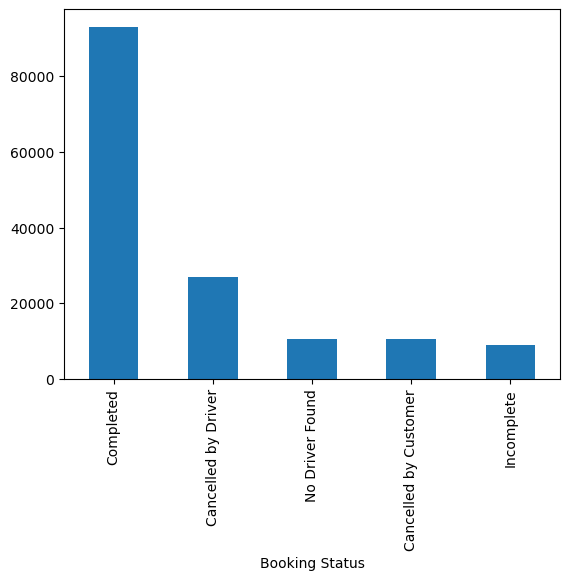

In [25]:
df['Booking Status'].value_counts().plot(kind='bar')

## ⏰ Booking Trend by Hour

This visualization represents the number of bookings across different hours of the day.

### Insights:
- Bookings increase during daytime and evening hours
- Peak demand is observed in evening hours
- Early morning hours show lower activity

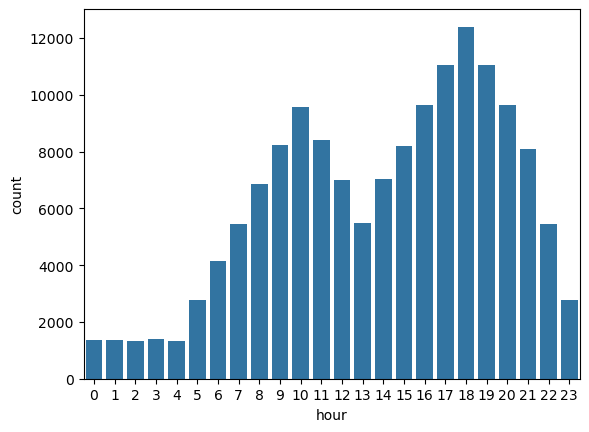

In [26]:
sns.countplot(x='hour', data=df)
plt.show()

<Axes: xlabel='Vehicle Type'>

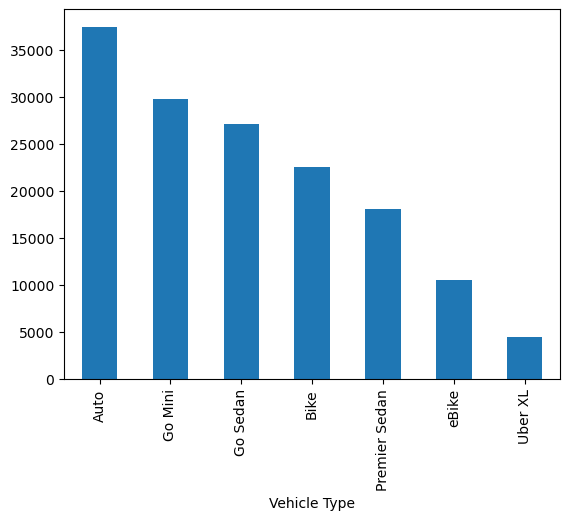

In [27]:
df['Vehicle Type'].value_counts().plot(kind='bar')

## 🔄 Vehicle Type vs Booking Status

This chart compares booking outcomes across different vehicle types.

### Insights:
- Economy vehicles have the highest number of completed rides
- Cancellation patterns vary slightly across vehicle types
- Some vehicle categories show higher driver cancellations

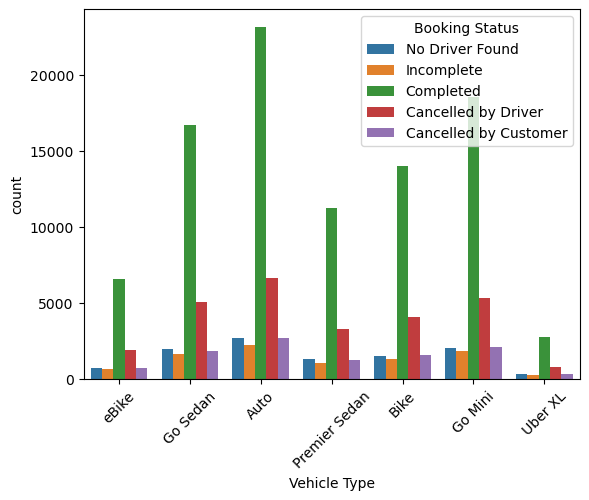

In [28]:
sns.countplot(x='Vehicle Type', hue='Booking Status', data=df)
plt.xticks(rotation=45)
plt.show()

## 🕒 Hour vs Booking Status

This chart shows how booking status varies across different hours.

### Insights:
- Peak hours show both high completion and cancellation
- Driver cancellations tend to increase during busy hours
- Off-peak hours have lower activity overall

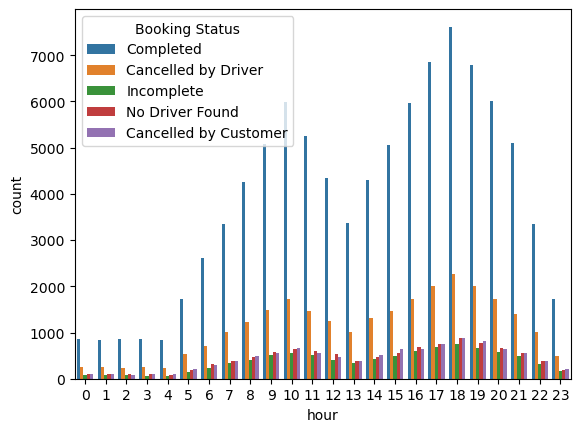

In [29]:
sns.countplot(x='hour', hue='Booking Status', data=df)
plt.show()

## 📏 Ride Distance by Vehicle Type

This boxplot shows the distribution of ride distances across vehicle types.

### Insights:
- Ride distances are fairly consistent across all vehicle types
- No major outliers or variation between categories
- Most rides fall within a similar distance range

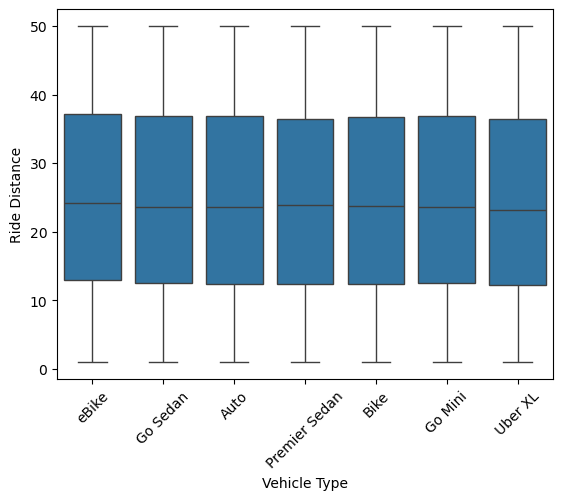

In [30]:
sns.boxplot(x='Vehicle Type', y='Ride Distance', data=df)
plt.xticks(rotation=45)
plt.show()

## 📈 Final Conclusion

- Majority of rides are completed successfully (~62%)
- Driver cancellations (18%) are significantly higher than customer cancellations (7%)
- Economy vehicle types dominate bookings and revenue
- Peak demand occurs during daytime and evening hours
- Ride distances remain consistent across vehicle types
- Driver ratings indicate good service quality

### Business Recommendations:
- Reduce driver cancellations through better incentives or monitoring
- Increase driver availability during peak hours
- Focus on high-demand locations for better ride allocation